## 97. Validation ICESat-2
0. Packages
1. Settings
2. Read Data
3. Plot data

### 0. Packages

In [49]:
# Packages
import colormaps as cmaps
import glob
import geopandas as gpd
import colormaps as cmaps
import numpy as np
import os
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import xarray as xr
import pandas as pd
from tqdm import tqdm
from geocube.api.core import make_geocube
from geocube.rasterize import rasterize_image
from functools import partial

from resilientplotterclass import rpclass

from scipy import stats
from scipy.stats import gaussian_kde

### 1. Settings

In [50]:
# File paths gtsm
file_path_gtsm_combined_zarr = r'p:\1230882-emodnet_hrsm\GTSMv3.0EMODnet\CMEMS_intertidal_SDB\zarr_files\gtsm_model_his_combined_v2.zarr'
file_path_gtsm_stations_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations_v2.parquet'

# File paths gebco
file_path_gebco_tif = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\03_gebco_files\gebco_2024.tif'
file_path_gebco_hat_lat_tif = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\03_gebco_files\gebco_2024_hat_lat.tif'

# File paths feasibility map
file_path_fm_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result.parquet'
file_path_fm_ed_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result_erosion_dilation.parquet'

# File paths tiles
file_path_tiles_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\AOI_polygons_world\df_boxes_world_Z10_filtered_v3.parquet'

# File paths osm
file_path_osm_tifs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_osm_files\water_rasters\*.tif')
file_path_osm_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_osm_files\geometries\osm_water_metadata.parquet'

# File paths sdbs
file_path_sdbs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_global\05_reprojected\*.tif')
file_path_sdbs = [file_path for file_path in file_path_sdbs if not file_path.endswith('.tif.aux.xml')]
file_path_sdbs = {os.path.basename(file_path).split('_t')[0]: file_path for file_path in file_path_sdbs}

# Dir path icesat-2
dir_path_icesats = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\06_validation\ICESAT-2\full\tiles\tiles\*')
dir_path_icesats = {os.path.basename(dir_path): dir_path for dir_path in dir_path_icesats if os.path.isdir(dir_path)}

In [51]:
# Define guidelines
gls = {
    'general':
        {'crs': 'EPSG:4326',
         'cartopy_bounds': [3.5, 7, 51, 54],
         'cartopy_features': ['land', 'ocean', 'lakes', 'coastline', 'borders']},
    'geom_style':
        {'gtsm': {'color': 'blue', 'markersize': 10, 'label': 'GTSM stations'},
         'tiles': {'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5, 'label': 'Tiles'},
         'feasibility_map': {'facecolor': 'blue', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map'},
         'feasibility_map_ed': {'facecolor': 'red', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map (erosion-dilation)'},
         'tiles nearest distance': {'column': 'nearest_station_distance', 'vmin': 0, 'vmax': 50, 'cmap': 'Greens_r', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Distance to nearest GTSM station [km]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles intertidal coverage': {'column': 'intertidal_coverage', 'vmin': 0, 'vmax': 100, 'cmap': 'Greens', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Intertidal coverage [%]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles filtered': {'facecolor': 'none', 'edgecolor': 'red', 'linewidth': 1.5, 'label': 'Filtered tiles'}},
    'extent_style':
        {'dutch waddenzee': {'xlim': [5.625000001956855, 6.328125001956671], 'ylim': [53.33087298454682, 53.540307393022395]}, #{'xlim': [5.2734375019479645, 5.976562501956762], 'ylim': [53.12040528463854, 53.540307393022395]},
         'german waddenzee': {'xlim': [7.0312500019654705, 7.73437500197427], 'ylim': [53.540307393022395, 53.956085532500275]}, #{'xlim': [8.085937501974177, 8.789062501982977], 'ylim': [53.540307393022395, 53.956085532500275]}, #
         'thames estuary': {'xlim': [0.3515625018953532, 1.0546875019041522], 'ylim': [51.39920565513004, 51.83577752201909]},
         'le mont-saint-michel': {'xlim': [-2.1093749981309524, -1.4062499981221528], 'ylim': [48.458351884449186, 48.9224992653895]},
         'pertuis d antioche': {'xlim': [-1.757812498122061, -1.054687498122245], 'ylim': [45.82879925362075, 46.31658418351273]},
        }
    }

# Set guidelines
rpc = rpclass(gls)

# Get guidelines
gls = rpc.get_guidelines()

# Get bounds and crs
crs = gls['general']['crs']
bounds = gls['general']['cartopy_bounds']

# Show guidelines
rpc.show_guidelines(open=False)

### 2. Read Data

In [52]:
# Read gtsm
ds_gtsm_combined = xr.open_zarr(file_path_gtsm_combined_zarr, consolidated=True)
gdf_gtsm_stations = gpd.read_parquet(file_path_gtsm_stations_parquet)

# Read feasibility map
gdf_fm = gpd.read_parquet(file_path_fm_parquet)
gdf_fm_ed = gpd.read_parquet(file_path_fm_ed_parquet)

# Read tiles
gdf_tiles = gpd.read_parquet(file_path_tiles_parquet)
gdf_tiles['nearest_station_distance'] = gdf_tiles['nearest_station_distance']/1000  # Convert to km
gdf_tiles['intertidal_coverage'] = gdf_tiles['intertidal_coverage']*100  # Convert to percentage
gdf_tiles['intertidal_coverage_ed'] = gdf_tiles['intertidal_coverage_ed']*100  # Convert to percentage
gdf_tiles['processed'] = (gdf_tiles['nearest_station_distance'] < 37) & (gdf_tiles['intertidal_coverage'] > 0) & (gdf_tiles['intertidal_coverage_ed'] > 1)
print('Number of tiles:', len(gdf_tiles))
print(gdf_tiles['processed'].value_counts())

# Add file path sdb to gdf_tiles
gdf_tiles['file_path_sdb'] = gdf_tiles['name'].apply(
    lambda x: file_path_sdbs.get(x, None)
)

# Add file path icesats to gdf_tiles
gdf_tiles['dir_path_icesat'] = gdf_tiles['name'].apply(
    lambda x: dir_path_icesats.get(x, None)
)

# Read osm
gdf_osm = gpd.read_parquet(file_path_osm_parquet)

Number of tiles: 38639
processed
True     27956
False    10683
Name: count, dtype: int64


In [53]:
def get_sdb_data(gdf_tiles, bounds, skip=1):
    # SDB data
    file_paths = [file_path for file_path in gdf_tiles['file_path_sdb'].values if file_path is not None]
    ds_sdb_ls = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in file_paths]
    ds_sdb_ls = [ds.rio.set_nodata(np.nan) for ds in ds_sdb_ls]
    ds_sdb_ls = [ds.rio.reproject(dst_crs=crs, resolution=ds.rio.resolution()[0]*skip) for ds in ds_sdb_ls]
    ds_sdb_ls = [ds.rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3], crs=crs) for ds in ds_sdb_ls]
    ds_sdb   = merge_arrays(ds_sdb_ls).rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3])

    return ds_sdb

def read_icesat_data(gdf_tiles):
    gdf_icesats_ls = []


    dir_path_icesats = [dir_path for dir_path in gdf_tiles['dir_path_icesat'] if dir_path is not None]
    for dir_path_icesat in dir_path_icesats:
        # Get all parquet files in the directory
        file_path_icesats = glob.glob(os.path.join(dir_path_icesat, '*.pq'))
        
        # Read each parquet file into a GeoDataFrame
        for _, file_path in enumerate(tqdm(file_path_icesats, desc=f'Reading data from {os.path.basename(dir_path_icesat)}')):
            gdf_icesat = gpd.read_parquet(file_path)
            gdf_icesat['file_path'] = file_path
            gdf_icesat['file_name'] = os.path.basename(file_path)
            gdf_icesats_ls.append(gdf_icesat)

    # Concatenate all GeoDataFrames
    gdf_icesat = gpd.GeoDataFrame(pd.concat(gdf_icesats_ls, ignore_index=True), crs=gdf_icesat.crs)

    # Sort by 'datetime' and 'file_name'
    gdf_icesat = gdf_icesat.sort_values(by=['datetime', 'file_name']).reset_index(drop=True)

    # Get unique file names sorted by datetime
    file_names = gdf_icesat['file_name'].unique()
    file_names_sorted = sorted(file_names, key=lambda x: gdf_icesat[gdf_icesat['file_name'] == x]['datetime'].min())

    # Add file_index based on sorted file names
    file_indices = {file_name: idx for idx, file_name in enumerate(file_names_sorted)}
    gdf_icesat['file_index'] = gdf_icesat['file_name'].map(file_indices)

    # Remove points where sensor depth is exceeded
    gdf_icesat = gdf_icesat[gdf_icesat['sensor_depth_exceeded'] == False]

    # Reproject to the specified CRS
    gdf_icesat = gdf_icesat.to_crs(crs)

    # Return the GeoDataFrame
    return gdf_icesat

def sample_at_points(da: xr.DataArray, gdf: gpd.GeoDataFrame, method: str = "nearest", to_gdf=False) -> xr.DataArray:
    """
    Sample an xarray DataArray at points defined in a GeoDataFrame.

    Args:
        da (DataArray): The DataArray to sample.
        gdf (geopandas.GeoDataFrame): The GeoDataFrame containing Point geometries.
        method (str, optional): The interpolation method to use. Defaults to "nearest".
        to_gdf (bool, optional): If True, return a GeoDataFrame instead of DataArray. Defaults to False.
    Returns:
        DataArray: The sampled DataArray with coordinates for each point.
    """

    # Compare coordinate reference systems
    if da.rio.crs != gdf.crs:
        raise ValueError(f"CRS mismatch between DataArray ({da.rio.crs.to_string()}) and GeoDataFrame ({gdf.crs.to_string()}).")

    # Check if GeoDataFrame contains points
    if not (gdf.geometry.type.isin(["Point"])).all():
        raise ValueError("GeoDataFrame must contain Point geometries. Explode MultiPoint geometries if necessary.")

    # Reset index of the GeoDataFrame
    index_name = gdf.index.name if gdf.index.name else 'index'
    gdf = gdf.reset_index()

    # Get coordinates of points
    x_coords = xr.DataArray([point.x for point in gdf.geometry], dims="point")
    y_coords = xr.DataArray([point.y for point in gdf.geometry], dims="point")

    # Interpolate the DataArray at the points
    da_sampled = da.interp(x=x_coords, y=y_coords, method=method)

    # Add the index coordinates to the sampled DataArray
    if index_name is not None:
        da_sampled = da_sampled.assign_coords(point=gdf[index_name])

    if not to_gdf:
        return da_sampled
    
    # Convert the sampled DataArray to a Dataset
    if 'band' in da_sampled.dims:
        ds_sampled = da_sampled.to_dataset('band').rename({band: f'band {band}' for band in da_sampled.band.values})
    else:
        ds_sampled = da_sampled.to_dataset(name='value')

    # Convert the Dataset to a DataFrame
    df_sampled = ds_sampled.to_dataframe().drop(columns='spatial_ref').reset_index(drop=True)

    # Join the DataArray with the GeoDataFrame
    gdf_sampled = gdf.join(df_sampled)

    # Reset the index of the GeoDataFrame
    if index_name is not None:
        gdf_sampled = gdf_sampled.set_index(index_name)
    if index_name == 'index':
        gdf_sampled.index.name = None

    return gdf_sampled

def rasterize(gdf: gpd.GeoDataFrame, measurements: list[str] = None, like: xr.Dataset = None, **kwargs: dict) -> xr.Dataset:
    """
    Convert a GeoDataFrame to a rasterized Dataset or GridDict.

    Args:
        gdf (gpd.GeoDataFrame): The GeoDataFrame to rasterize.
        measurements (list[str], optional): List of measurements to include in the rasterization.
        like (xr.Dataset, optional): A reference Dataset to match the output dimensions and CRS.
        **kwargs: Additional keyword arguments for rasterization.

    Returns:
        Union[xr.Dataset, mp.GridDict]: A rasterized Dataset or GridDict containing the rasterized data.
    """
    # Set default rasterize function if not provided
    kwargs.setdefault("rasterize_function", partial(rasterize_image, all_touched=True))

    # Rasterize the GeoDataFrame to a Dataset
    ds = make_geocube(vector_data=gdf, measurements=measurements, like=like, **kwargs)

    # Remove names from the Dataset
    for var in ds.data_vars:
        if "name" in ds[var].attrs:
            ds[var].attrs.pop("name")

    # Return a DataArray if one variable is present
    if len(ds.data_vars) == 1:
        da = ds[list(ds.data_vars)[0]]
        da.name = None
        return da
    
    # Return a Dataset if multiple variables are present
    return ds

def process_icesat_data(gdf_icesat, ds_sdb, depth_theshold=np.inf):
    # Sample SDB data at ICESat-2 points
    gdf_sdb = sample_at_points(
        da=ds_sdb.isel(band=0),
        gdf=gdf_icesat,
        to_gdf=True
    ).rename(columns={'value': 'sdb'})

    # Merge the GeoDataFrame with the sampled SDB data
    gdf_icesat = gdf_icesat.merge(gdf_sdb)

    # Remove rows where SDB data is NaN
    gdf_icesat = gdf_icesat[~gdf_icesat['sdb'].isna()]

    # Calculate difference between orthometric height and SDB
    gdf_icesat['difference'] = gdf_icesat['orthometric_height'] - gdf_icesat['sdb']

    # Calculate depth
    gdf_icesat['depth'] = gdf_icesat['surface_height'] - gdf_icesat['orthometric_height']

    # Remove rows where depth > depth_theshold
    gdf_icesat = gdf_icesat[gdf_icesat['depth'] < depth_theshold]

    # Return the processed GeoDataFrame
    return gdf_icesat

# Get bounds
print('Getting bounds')
extents = gls['extent_style']
bounds_dwz = [extents['dutch waddenzee']['xlim'][0], extents['dutch waddenzee']['ylim'][0], extents['dutch waddenzee']['xlim'][1], extents['dutch waddenzee']['ylim'][1]]
bounds_gwz = [extents['german waddenzee']['xlim'][0], extents['german waddenzee']['ylim'][0], extents['german waddenzee']['xlim'][1], extents['german waddenzee']['ylim'][1]]
bounds_the = [extents['thames estuary']['xlim'][0], extents['thames estuary']['ylim'][0], extents['thames estuary']['xlim'][1], extents['thames estuary']['ylim'][1]]
bounds_msm = [extents['le mont-saint-michel']['xlim'][0], extents['le mont-saint-michel']['ylim'][0], extents['le mont-saint-michel']['xlim'][1], extents['le mont-saint-michel']['ylim'][1]]
bounds_pda = [extents['pertuis d antioche']['xlim'][0], extents['pertuis d antioche']['ylim'][0], extents['pertuis d antioche']['xlim'][1], extents['pertuis d antioche']['ylim'][1]]

# Get tiles within bounds
print('Getting tiles within bounds')
gdf_tiles_dwz = gdf_tiles.cx[bounds_dwz[0]:bounds_dwz[2], bounds_dwz[1]:bounds_dwz[3]]
gdf_tiles_gwz = gdf_tiles.cx[bounds_gwz[0]:bounds_gwz[2], bounds_gwz[1]:bounds_gwz[3]]
gdf_tiles_the = gdf_tiles.cx[bounds_the[0]:bounds_the[2], bounds_the[1]:bounds_the[3]]
gdf_tiles_msm = gdf_tiles.cx[bounds_msm[0]:bounds_msm[2], bounds_msm[1]:bounds_msm[3]]
gdf_tiles_pda = gdf_tiles.cx[bounds_pda[0]:bounds_pda[2], bounds_pda[1]:bounds_pda[3]]

# Get sdb data
print('Getting SDB data')
ds_sdb_dwz = get_sdb_data(gdf_tiles_dwz, bounds_dwz)
ds_sdb_gwz = get_sdb_data(gdf_tiles_gwz, bounds_gwz)
ds_sdb_the = get_sdb_data(gdf_tiles_the, bounds_the)
ds_sdb_msm = get_sdb_data(gdf_tiles_msm, bounds_msm)
ds_sdb_pda = get_sdb_data(gdf_tiles_pda, bounds_pda)

# Read ICESat-2 data
print('Reading ICESat-2 data')
gdf_icesat_dwz = read_icesat_data(gdf_tiles_dwz)
gdf_icesat_gwz = read_icesat_data(gdf_tiles_gwz)
gdf_icesat_the = read_icesat_data(gdf_tiles_the)
gdf_icesat_msm = read_icesat_data(gdf_tiles_msm)
gdf_icesat_pda = read_icesat_data(gdf_tiles_pda)

# Process ICESat-2 data
print('Processing ICESat-2 data')
gdf_icesat_dwz = process_icesat_data(gdf_icesat_dwz, ds_sdb_dwz, depth_theshold=5)
gdf_icesat_gwz = process_icesat_data(gdf_icesat_gwz, ds_sdb_gwz, depth_theshold=5)
gdf_icesat_the = process_icesat_data(gdf_icesat_the, ds_sdb_the, depth_theshold=8)
gdf_icesat_msm = process_icesat_data(gdf_icesat_msm, ds_sdb_msm, depth_theshold=8)
gdf_icesat_pda = process_icesat_data(gdf_icesat_pda, ds_sdb_pda, depth_theshold=5)

Getting bounds
Getting tiles within bounds
Getting SDB data
Reading ICESat-2 data


Reading data from z10_x508_y364: 100%|██████████| 210/210 [00:04<00:00, 46.33it/s]


Processing ICESat-2 data


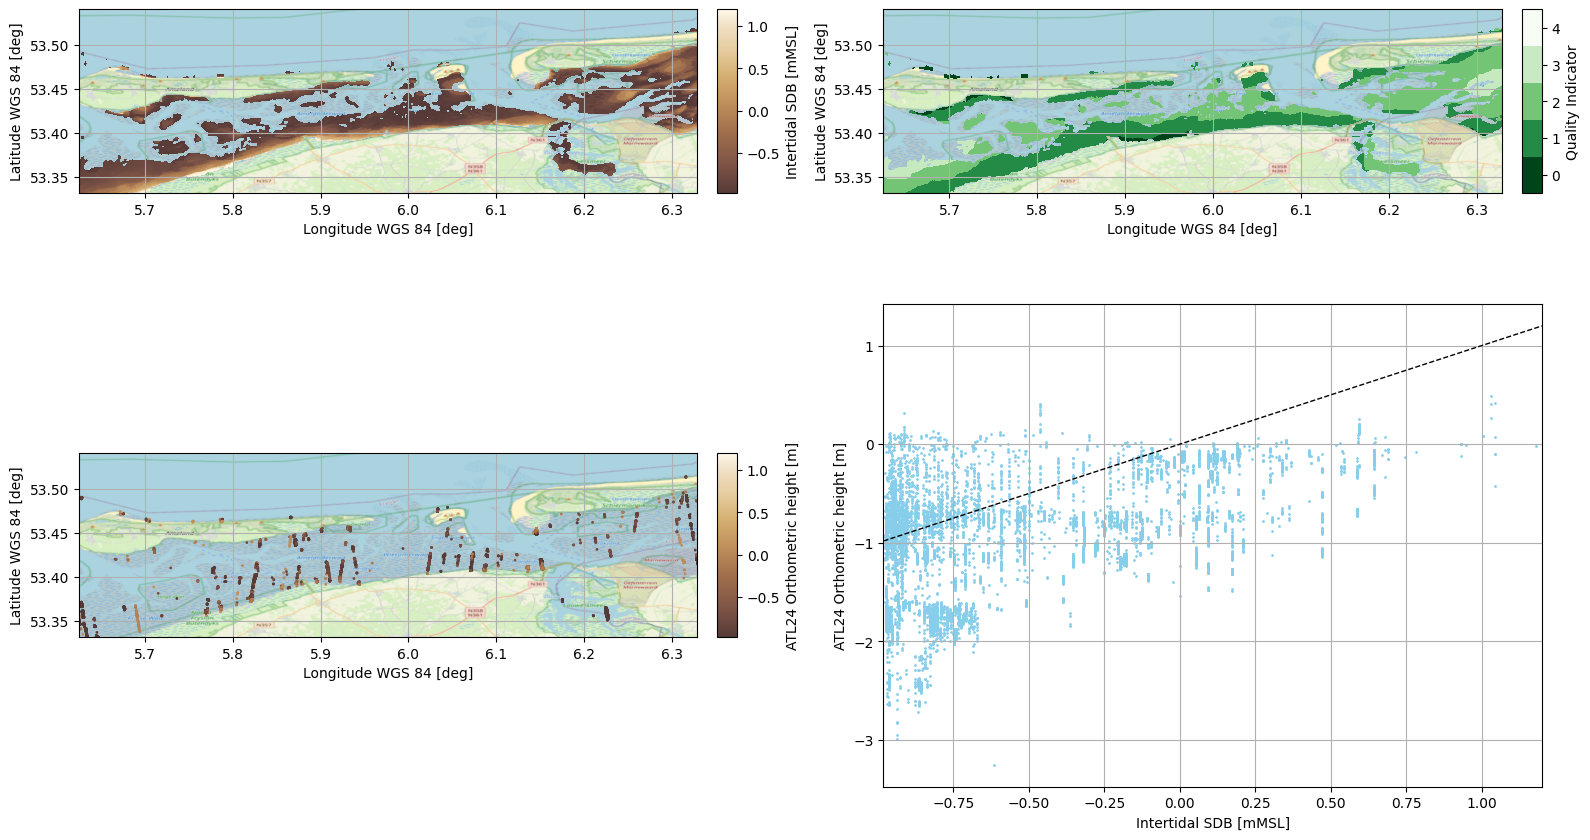

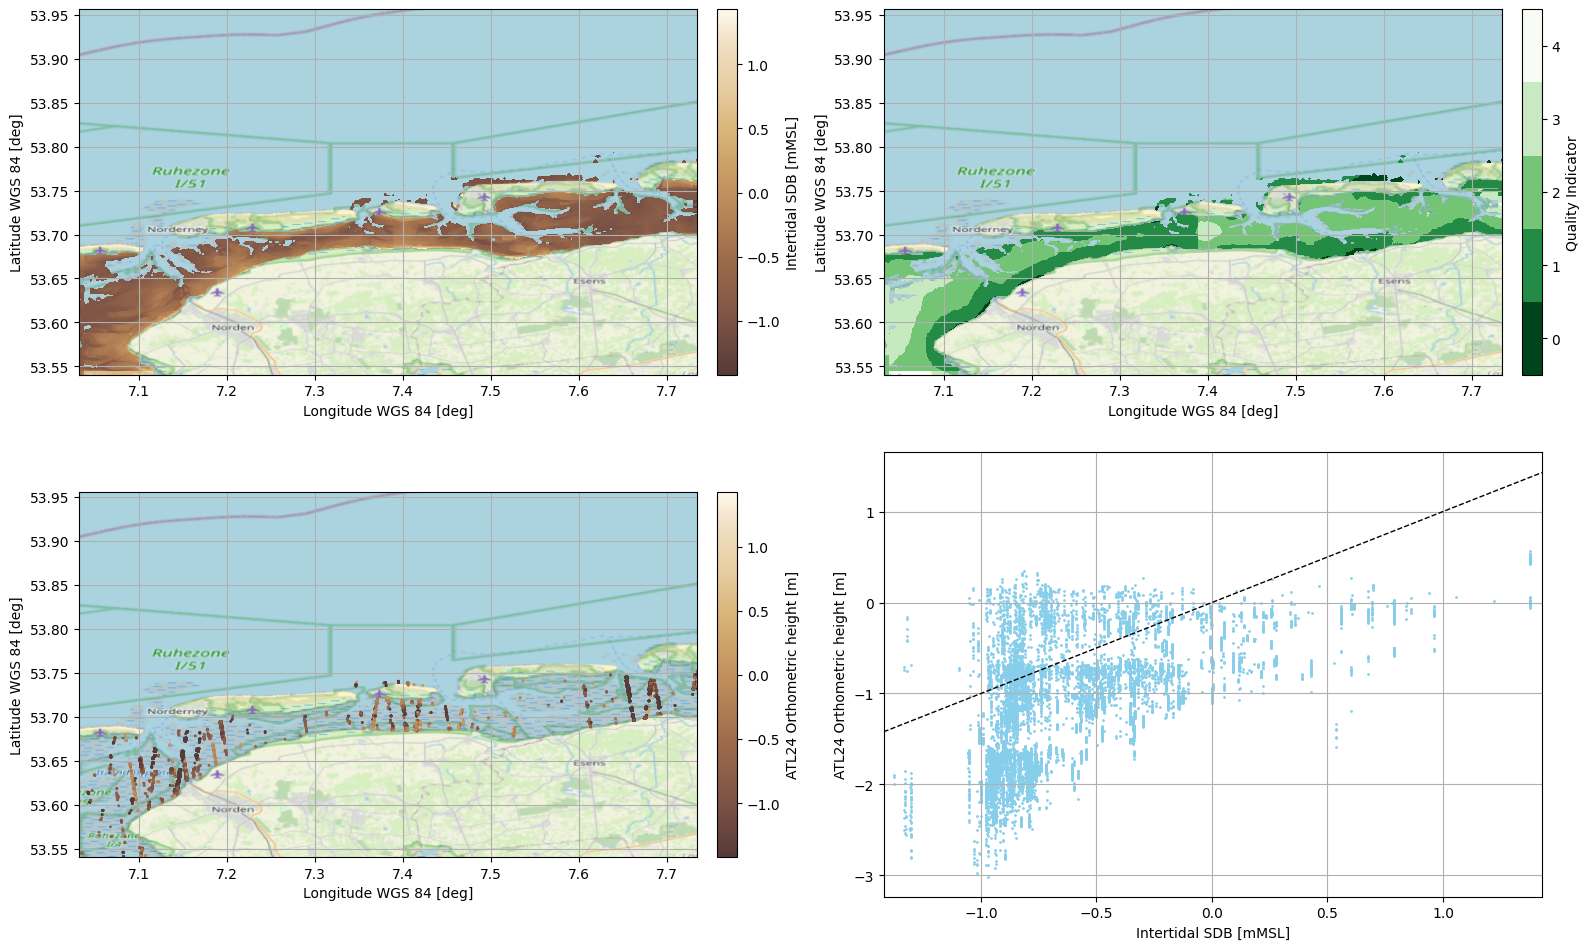

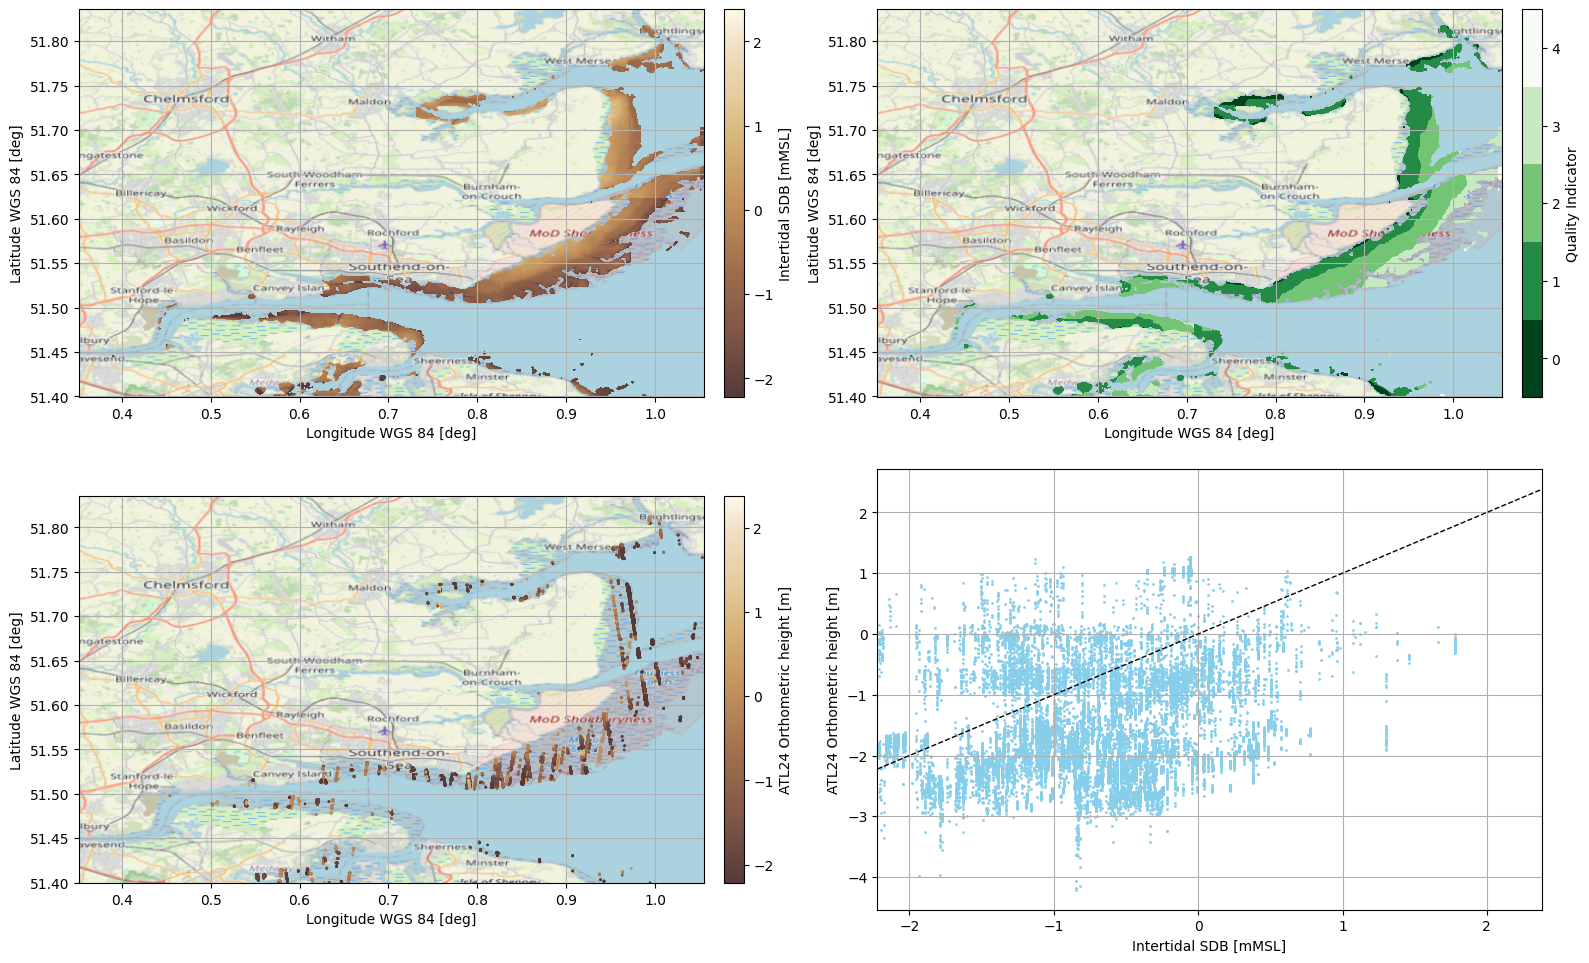

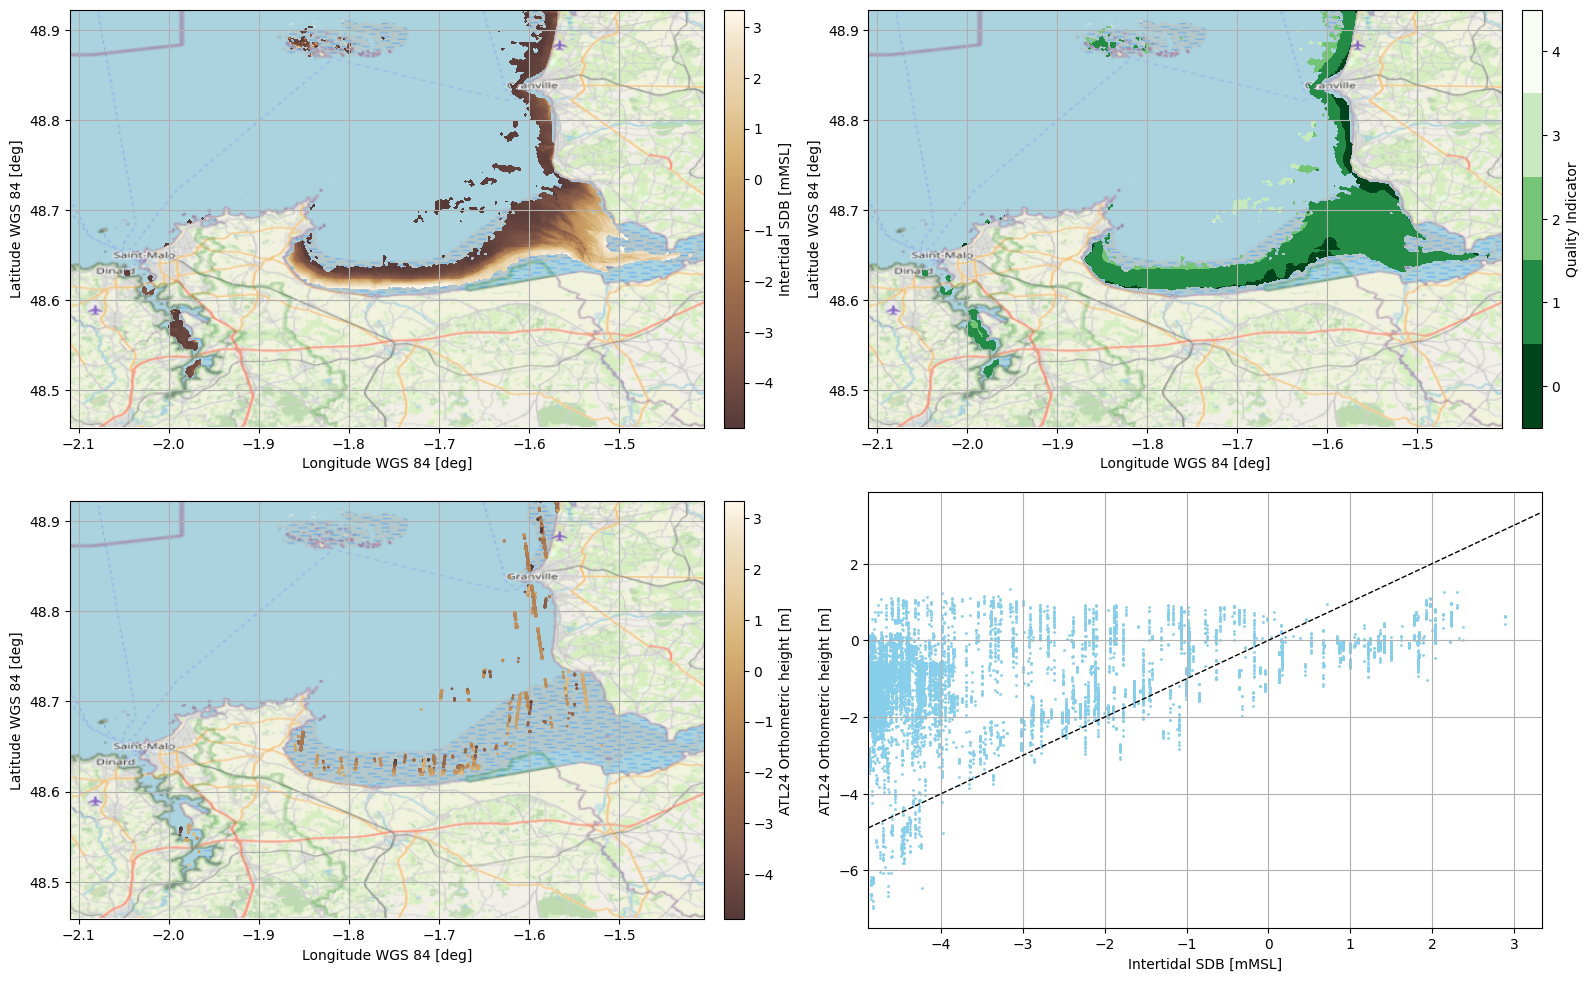

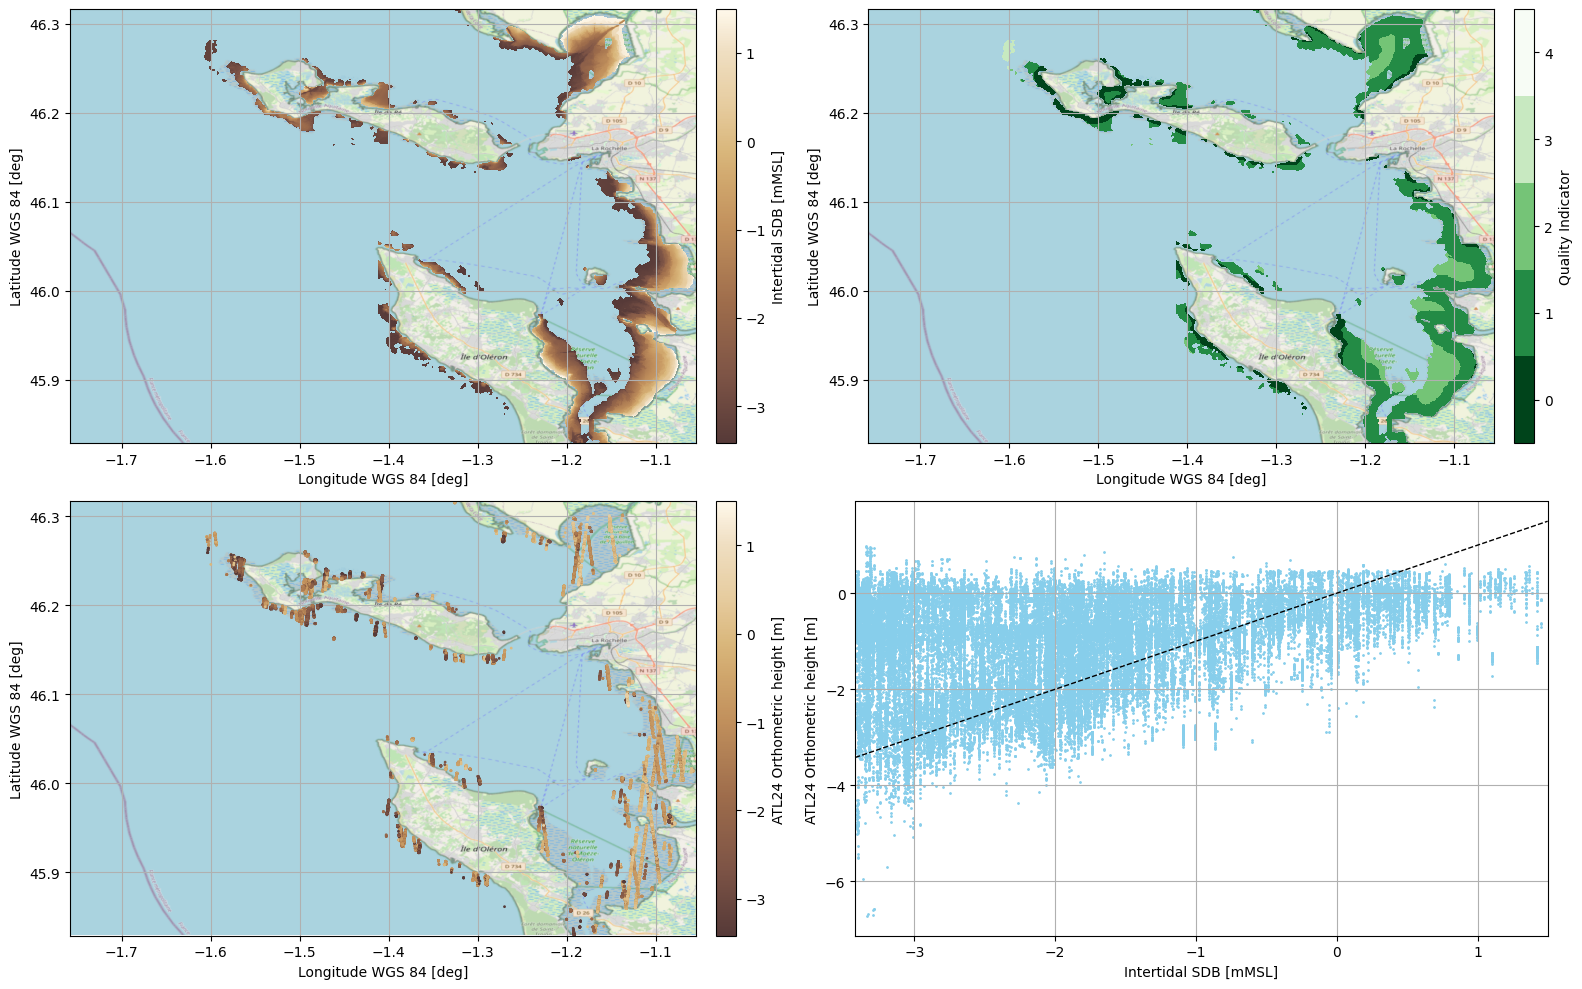

In [71]:
import scipy
def calculate_statistics(x, y):
    # Remove nans
    idx_nans = np.logical_or(np.isnan(x), np.isnan(y))
    x = x[~idx_nans]
    y = y[~idx_nans]

    # Get statistics
    stats = {}
    if len(x) > 2:
        stats['spearman_r'] = scipy.stats.spearmanr(x, y).correlation # Spearman rank-order correlation coefficient (1 = perfect correlation)
        stats['pearson_r'] = scipy.stats.pearsonr(x, y)[0]            # Pearson correlation coefficient (1 = perfect correlation)
        stats['r2'] = scipy.stats.linregress(x, y).rvalue**2          # Coefficient of determination (1 = perfect correlation)
        stats['rmse'] = np.sqrt(np.mean((x - y)**2))            # Root Mean Squared Error (lower is better)
        stats['mae'] = np.mean(np.abs(x - y))                   # Mean Absolute Error (lower is better)
    else:
        stats['spearman_r'] = np.nan
        stats['pearson_r'] = np.nan
        stats['r2'] = np.nan
        stats['rmse'] = np.nan
        stats['mae'] = np.nan

    return stats

from scipy.interpolate import interpn
def density_scatter(x, y, ax, sort = True, bins = 20, **kwargs):
    # Remove nans
    idx_nans = np.logical_or(np.isnan(x), np.isnan(y))
    x = x[~idx_nans]
    y = y[~idx_nans]
    
    data , x_e, y_e = np.histogram2d( x, y, bins = bins, density = True )
    z = interpn( ( 0.5*(x_e[1:] + x_e[:-1]) , 0.5*(y_e[1:]+y_e[:-1]) ) , data , np.vstack([x, y]).T , method = "splinef2d", bounds_error = False)

    #To be sure to plot all data
    z[np.where(np.isnan(z))] = 0.0

    # Sort the points by density, so that the densest points are plotted last
    if sort :
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]

    # Create a scatter plot
    ax.scatter(x, y, c=z, **kwargs)

    return ax

def plot_statistics(stats, ax):
    text = '\n'.join(['Spearman $\\rho$ {:.2f}'.format(stats['spearman_r']),
                        'Pearson $\\rho$: {:.2f}'.format(stats['pearson_r']),
                        'R²:        {:.2f}'.format(stats['r2']),
                        'RMSE:      {:.2f} m'.format(stats['rmse']),
                        'MAE:       {:.2f} m'.format(stats['mae'])])
    ax.text(0.02, 0.978, text, color='black', transform=ax.transAxes, verticalalignment='top', family='monospace', linespacing=1.5,
            bbox=dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.2'))

def plot_data(ds_sdb, gdf_icesat, extent_style, vmin=None, vmax=None):
    # Calculate statistics
    x = gdf_icesat['sdb'].values.flatten()
    y = gdf_icesat['orthometric_height'].values.flatten()
    stats = calculate_statistics(x, y)
    
    # Get vmin and vmax
    if vmin is None:
        vmin = ds_sdb.isel(band=0).min().values
    if vmax is None:
        vmax = ds_sdb.isel(band=0).max().values

    # Create figure and axis
    fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
    axs = axs.flatten()

    # Plot SDB data
    rpc.imshow(ds_sdb.isel(band=0), ax=axs[0], data_style='default', cbar_kwargs={'label': 'Intertidal SDB [mMSL]'}, cmap=cmaps.brown_sable, vmin=vmin, vmax=vmax)

    # Plot SDB quality indicator
    import matplotlib as mpl
    cmap = mpl.colors.ListedColormap(mpl.colormaps['Greens_r'](np.linspace(0, 1, 5)))
    rpc.imshow(ds_sdb.isel(band=1), ax=axs[1], data_style='default', cbar_kwargs={'label': 'Quality Indicator'}, vmin=-0.5, vmax=4.5, cmap=cmap)

    # Plot ICESat-2 data
    rpc.geometries(gdf_icesat, geom_style='default', column='orthometric_height', ax=axs[2], cmap=cmaps.brown_sable, s=1, legend=True, legend_kwds={'label': 'ATL24 Orthometric height [m]'}, vmin=vmin, vmax=vmax)

    # Plot basemaps
    for ax in axs[0:3]:
        rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style=extent_style)
    
    # Plot statistics
    x = gdf_icesat['sdb'].values.flatten()
    y = gdf_icesat['orthometric_height'].values.flatten()
    #density_scatter(x, y, axs[3], sort=True, bins=, cmap='Blues', s=1)
    axs[3].scatter(x, y, c='skyblue', s=1)
    #plot_statistics(stats, axs[3])
    axs[3].plot([vmin, vmax], [vmin, vmax], color='black', linestyle='--', linewidth=1)
    axs[3].set_xlabel('Intertidal SDB [mMSL]')
    axs[3].set_ylabel('ATL24 Orthometric height [m]')
    axs[3].set_xlim(vmin, vmax)
    axs[3].grid()

    # Show figure
    rpc.show(fig=fig)

plot_data(ds_sdb_dwz, gdf_icesat_dwz, extent_style='dutch waddenzee')
plot_data(ds_sdb_gwz, gdf_icesat_gwz, extent_style='german waddenzee')
plot_data(ds_sdb_the, gdf_icesat_the, extent_style='thames estuary')
plot_data(ds_sdb_msm, gdf_icesat_msm, extent_style='le mont-saint-michel')
plot_data(ds_sdb_pda, gdf_icesat_pda, extent_style='pertuis d antioche')